In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from fastai.collab import *
from fastai.tabular.all import *
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error

check GPU

In [ ]:
import torch

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_parquet("/content/drive/MyDrive/USTH/Fundamental of DS/dataset/10ubr.parquet")
df.sample(5)

,user_id,book_id,rating
9668884,3db57828e97d23444e979b9dc0ebe7a3,6381205,5
4095350,3e7170f87ae4014dcb1c5bc8afa67907,106264,2
8612635,9ecbf2db09beb8651a46a174a84cde62,7937462,3
5402442,81d0ee97d58b58b3a94ffac062dc23d3,16328,4
1196669,4e714ac27123c9535a8a9430b2536cb1,188258,5


In [ ]:
book_mart = pd.read_parquet("/content/drive/MyDrive/USTH/Fundamental of DS/dataset/mart_book_statistics.parquet")

In [ ]:
df.shape

(10000000, 3)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 3 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   user_id  object
 1   book_id  int32 
 2   rating   int32 
dtypes: int32(2), object(1)
memory usage: 152.6+ MB


# Train Model (Baseline)

In [ ]:
dls = CollabDataLoaders.from_df(
    df,
    user_name='user_id',
    item_name='book_id',
    rating_name='rating',
    valid_pct=0.2,
    seed=67
)

In [ ]:
dls.show_batch()

,user_id,book_id,rating
0,73d16e887c2256ed6f162a7576068fd4,18405,5
1,f5badac3081c591aca03d0dcf23ea795,8525590,5
2,f63bf67b8f82a0d98a46654601e71a07,252577,2
3,7f1effe03c7347d78a6394a51e72fa16,1618,5
4,a44fe2214f0e93999d64cc67f0874953,37451,3
5,707a0b54e4a70253c0275b6c0e00da4a,30244,5
6,8e2effb13f48a25afacfc7e964c05f56,18260387,4
7,244ea8d93ae2c372488805378de50f2c,13538873,4
8,50514cdba99fe689b1094a3b8f36e1d6,77392,4
9,e7440f8da8571be3152322368e0caff9,23675430,5


In [ ]:
print("Number of users:", len(dls.classes['user_id']))
print("Number of books:", len(dls.classes['book_id']))

Number of users: 433432
Number of books: 628131


In [ ]:
print("Number of training batches:", len(dls.train))
print("Number of validation batches:", len(dls.valid))

Number of training batches: 125000
Number of validation batches: 31250


In [ ]:
learn = collab_learner(
    dls,
    n_factors=50,
    y_range=(0, 5.5),
    metrics=[rmse]
)

In [ ]:
learn.model

EmbeddingDotBias(
  (u_weight): Embedding(433432, 50)
  (i_weight): Embedding(628131, 50)
  (u_bias): Embedding(433432, 1)
  (i_bias): Embedding(628131, 1)
)

Baseline

In [ ]:
learn.fit_one_cycle(
    1,
    5e-3,
    wd=0.1
)

epoch,train_loss,valid_loss,time
0,1.638761,1.623440,1:03:40


In [ ]:
learn.export(f"/content/drive/MyDrive/USTH/Fundamental of DS/10ubr_1.pkl")

Main

In [ ]:
learn.fit_one_cycle(
    3,
    lr_max=5e-3,
    wd=0.1
)

epoch,train_loss,valid_loss,_rmse,time
0,1.701114,1.670814,1.292601,1:03:03
1,1.627531,1.647930,1.283717,1:03:45
2,1.559677,1.609338,1.268596,1:04:51


In [ ]:
learn.export(f"/content/drive/MyDrive/USTH/Fundamental of DS/10ubr_2.pkl")

# Predict

select user (here i take the user among the most rating)

In [ ]:
user_counts = df['user_id'].value_counts()

user_id = user_counts.index[0]

print("Selected user:", user_id)
print("Number of ratings:", user_counts.iloc[0])

Selected user: c5823767a1a164cd8e9d029f1806f2aa
Number of ratings: 2638


In [ ]:
user_history = df[df['user_id'] == user_id].copy()

user_history = user_history.sort_values('rating',ascending=False)

user_history.head(10)

,user_id,book_id,rating
9912025,c5823767a1a164cd8e9d029f1806f2aa,18798983,5
969,c5823767a1a164cd8e9d029f1806f2aa,7695993,5
1066,c5823767a1a164cd8e9d029f1806f2aa,26138446,5
1633,c5823767a1a164cd8e9d029f1806f2aa,18668041,5
3587,c5823767a1a164cd8e9d029f1806f2aa,25829774,5
5010,c5823767a1a164cd8e9d029f1806f2aa,23365776,5
5894,c5823767a1a164cd8e9d029f1806f2aa,384771,5
6874,c5823767a1a164cd8e9d029f1806f2aa,2359225,5
7001,c5823767a1a164cd8e9d029f1806f2aa,20262813,5
7794,c5823767a1a164cd8e9d029f1806f2aa,7046126,5


In [ ]:
model = learn.model

In [ ]:
user_idx = dls.classes['user_id'].o2i[user_id]
user_emb = model.u_weight.weight[user_idx]
user_bias = model.u_bias.weight[user_idx]

book_emb = model.i_weight.weight
book_bias = model.i_bias.weight.squeeze()

scores = book_emb @ user_emb + user_bias + book_bias

In [ ]:
rated_books = set(user_history['book_id'])

book_to_idx = dls.classes['book_id'].o2i

rated_indices = []
for book_id in rated_books:
    if book_id in book_to_idx:
        rated_indices.append(book_to_idx[book_id])

scores[rated_indices] = -float('inf')

In [ ]:
top_scores, top_indices = torch.topk(scores, 10)

recommendation_list = []
for i in range(10):
    book_index = top_indices[i].item()
    book_id = dls.classes['book_id'][book_index]
    recommendation_score = top_scores[i].item()

    recommendation_list.append({'book_id': book_id, 'recommendation_score': recommendation_score})

recommendations = pd.DataFrame(recommendation_list)

In [ ]:
result = pd.merge(
    recommendations,
    book_mart[['book_id', 'title', 'author_names']],
    on='book_id',
    how='left'
)

result

,book_id,recommendation_score,title,author_names
0,136251,13.390967,"Harry Potter and the Deathly Hallows (Harry Potter, #7)","[J.K. Rowling, Mary GrandPre]"
1,17927395,12.927283,"A Court of Mist and Fury (A Court of Thorns and Roses, #2)",[Sarah J. Maas]
2,2657,12.762383,To Kill a Mockingbird,[Harper Lee]
3,34,12.433817,"The Fellowship of the Ring (The Lord of the Rings, #1)",[J.R.R. Tolkien]
4,2,12.400644,"Harry Potter and the Order of the Phoenix (Harry Potter, #5)","[J.K. Rowling, Mary GrandPre]"
5,186074,12.347522,"The Name of the Wind (The Kingkiller Chronicle, #1)",[Patrick Rothfuss]
6,2802316,11.234052,"Shadow Kiss (Vampire Academy, #3)",[Richelle Mead]
7,14935,10.791515,Sense and Sensibility,"[Jane Austen, Ros Ballaster, Tony Tanner]"
8,10210,10.653786,Jane Eyre,"[Charlotte Brontë, Michael Mason]"
9,7896527,10.625535,"Throne of Glass (Throne of Glass, #1)",[Sarah J. Maas]


# Overview

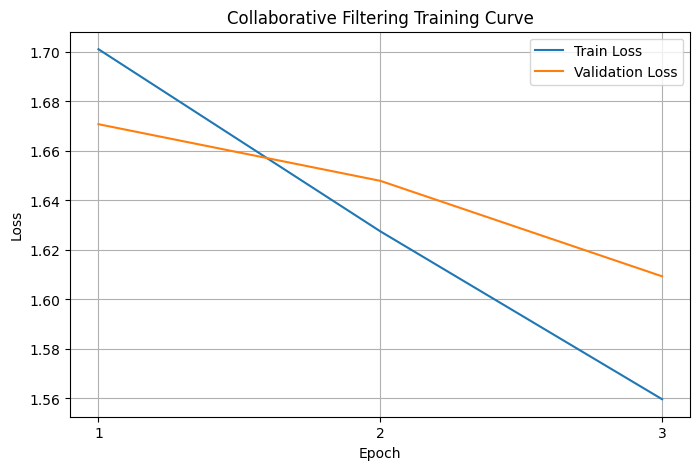

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(learn.recorder.values) + 1)

train_loss = [x[0] for x in history]
valid_loss = [x[1] for x in history]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, valid_loss, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Collaborative Filtering Training Curve')
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("========== DATASET ==========")
print(f"Interactions: {len(df):,}")
print(f"Users: {df['user_id'].nunique():,}")
print(f"Books: {df['book_id'].nunique():,}")
print(f"Rating range: {df['rating'].min()} - {df['rating'].max()}")
print(f"Average rating: {df['rating'].mean():.4f}")

print("\n========== MODEL ==========")
print(f"Latent factors: 50")
print(f"Learning rate: 0.005")
print(f"Weight decay: 0.1")
print(f"Epochs: 3")
print(f"Train batches: {len(dls.train):,}")
print(f"Validation batches: {len(dls.valid):,}")

print("\n========== EMBEDDINGS ==========")
print(f"User embedding shape: {learn.model.u_weight.weight.shape}")
print(f"Book embedding shape: {learn.model.i_weight.weight.shape}")

========== DATASET ==========
Interactions: 10,000,000
Users: 433,431
Books: 658,289
Rating range: 1 - 5
Average rating: 3.9390

========== MODEL ==========
Latent factors: 50
Learning rate: 0.005
Weight decay: 0.1
Epochs: 3
Train batches: 125,000
Validation batches: 31,250

========== EMBEDDINGS ==========
User embedding shape: torch.Size([433432, 50])
Book embedding shape: torch.Size([628131, 50])


In [ ]:
# evaluation

valid_loss, valid_rmse = learn.validate()
preds, targets = learn.get_preds(dl=dls.valid)
preds = preds.squeeze()
targets = targets.squeeze()

mae = mean_absolute_error(
    targets.cpu().numpy(),
    preds.cpu().numpy()
)

print("========== FINAL EVALUATION ==========")
print(f"Validation Loss : {valid_loss:.4f}")
print(f"RMSE            : {valid_rmse:.4f}")
print(f"MAE             : {mae:.4f}")

========== FINAL EVALUATION ==========
Validation Loss : 1.6093
RMSE            : 1.2686
MAE             : 1.0613


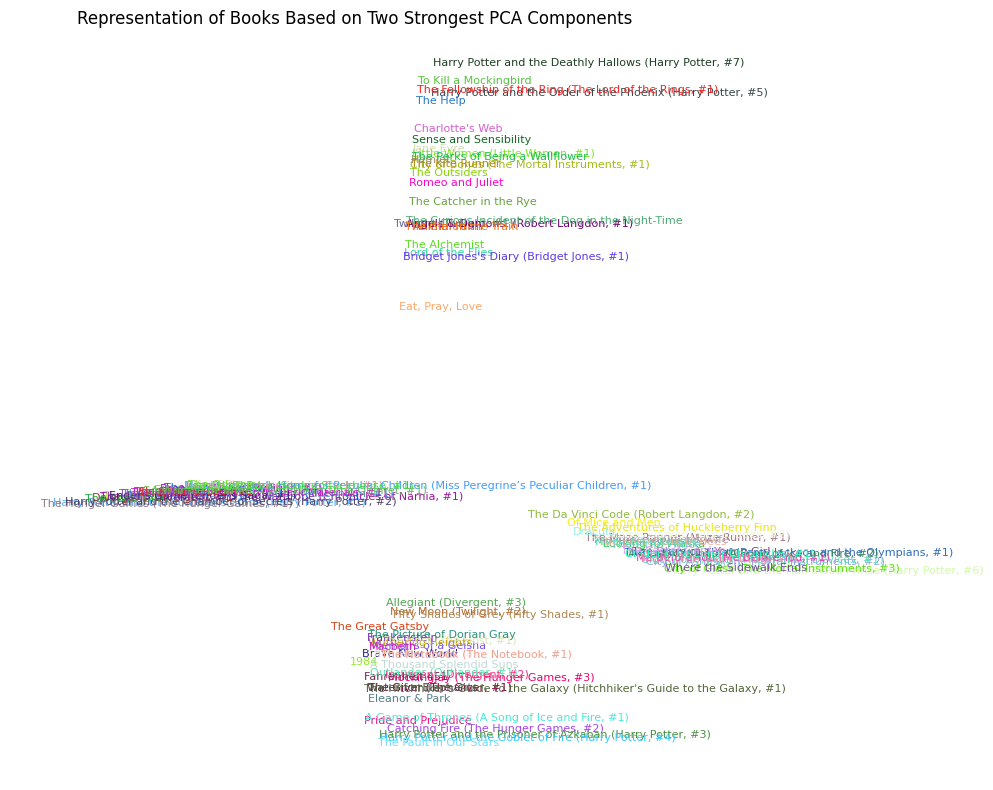

In [72]:
top_books = df.groupby('book_id')['rating'].count().sort_values(ascending=False).index.values[:1000]

book2idx = learn.dls.classes['book_id'].o2i
top_idxs = torch.tensor([
    book2idx[b]
    for b in top_books
    if b in book2idx
])

book_weight = (
    learn.model.i_weight.weight[top_idxs]
    .detach()
    .cpu()
)

book_pca = book_weight.pca(2)
fac0, fac1 = book_pca.T


top_books_df = pd.DataFrame({'book_id': top_books[:len(top_idxs)]})
top_books_df = pd.merge(
    top_books_df,
    book_mart[['book_id', 'title', 'author_names']],
    on='book_id',
    how='left'
)

idxs = list(range(min(100, len(top_books_df))))
X = fac0[idxs].numpy()
Y = fac1[idxs].numpy()
titles = top_books_df.iloc[idxs]['title'].fillna('Unknown').values


# plot
plt.figure(figsize=(10, 8))
plt.scatter(X,Y,alpha=0)
for title, x, y in zip(titles, X, Y):
    plt.text(x, y, title, color=np.random.rand(3), fontsize=8)
plt.title('Representation of Books Based on Two Strongest PCA Components')
plt.axis('off')
plt.tight_layout()
plt.show()